# 🔮 Chronos Demo: Rossmann Filiale 1097
### Zero-Shot Forecasting mit einem Foundation Model

*Gegenstück zur Prophet-Demo – **gleiche Daten**, damit wir direkt vergleichen können.*

Roter Faden: **Klassische Baselines** (Naive, Seasonal Naive) → **Chronos** (zero-shot) → **Prophet** (Analyst-in-the-Loop mit Feiertagen & Promo).

**Demo-Ablauf (Run All oder Schritt für Schritt)**

| Abschnitt | Modell / Methode | Prophet-Parallele |
|:---:|:---|:---|
| 1b | *(optional)* Schließtage & Equidistanz | Datenqualität |
| 2 | Chronos Zero-Shot Baseline | Prophet Modell 1 |
| 3–4 | Chronos Hebel (Kontext, Größe) | + Feiertage / NRW |
| 5 | Chronos-2 + Promo | + Regressor Promo |
| 6–7 | Intervalle & Black Swan | wie Prophet |
| 8 | **Vergleich** Chronos · klassisch · Prophet | Fazit |

> **Chronos ≠ trainieren:** `from_pretrained` lädt ein **vortrainiertes** Foundation Model. Es gibt **kein** `fit()` auf Filiale 1097 – `y_train` ist nur **Kontext** (Historie) für die Prognose. Prophet passt sich dagegen pro Serie mit `model.fit()` an.

> Prophet-Zahlen aus [`1_prophet_demo_final.ipynb`](../../prophet/notebooks/1_prophet_demo_final.ipynb). Klassische Baselines rechnen wir in **Abschnitt 8** auf **demselben Test** (42 Tage).

> **Live-Demo:** Notebook einmal **Run All** durchspielen (Modell-Downloads ~5–10 Min.). In der Präsentation bei **Abschnitt 8.3** einsteigen – Story: *erst fair (Baseline), dann unfair (Experte vs. zero-shot)*.


---
## 0 · Setup

Chronos braucht `chronos-forecasting` (+ PyTorch) und `scikit-learn` für Metriken und die **klassischen Baselines** in Abschnitt 8. Wir bewerten mit **denselben Metriken** wie bei Prophet (RMSE, MAE, MAPE).

> Umgebung: `conda env create -f ../ts-tutorial.yml` (wie beim Prophet-Teil).


In [1]:
# Einmalig installieren, falls noch nicht in der Env:
# !pip install chronos-forecasting scikit-learn

import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from chronos import BaseChronosPipeline

np.random.seed(42)
torch.manual_seed(42)
print('Setup ok - torch', torch.__version__)

Setup ok - torch 2.5.1+cpu


In [2]:
# Metrik-Helfer (gleiche Logik wie in der Prophet-Demo, damit die Zahlen vergleichbar sind)
def print_metrics(y_true, y_pred, label='Modell'):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f'{label:<32} RMSE={rmse:8.1f}  MAE={mae:8.1f}  MAPE={mape:5.1f}%')
    return {'label': label, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

---
## 1 · Daten laden (Filiale 1097)

Exakt wie bei Prophet: nur **geöffnete Tage** mit Umsatz, Filiale 1097 (Köln Hbf), chronologisch sortiert.

> **Train/Test-Split:** `y_train` = Historie für die Prognose, `y_test` = 42 Tage zum Bewerten. Das ist **kein** Chronos-Training – nur die Aufteilung der Zeitreihe.

> **Equidistanz:** Chronos Bolt interpretiert jeden Index in `y_train` als **einen gleich weiten Zeitschritt**. Filiale **1097** ist ein Sonderfall: im Datensatz **keine Schließtage** → die gefilterte Serie ist **täglich lückenlos**. Bei Filialen mit Schließtagen entstehen Kalenderlücken – siehe **Abschnitt 1b**.


In [3]:
train = pd.read_csv('../data/rossmann-store-sales/train.csv',
                    parse_dates=['Date'], low_memory=False)

store = 1097
df = (train[(train['Store'] == store) & (train['Open'] == 1) & (train['Sales'] > 0)]
      .sort_values('Date')
      .reset_index(drop=True))

print(f'Filiale {store}: {len(df)} geöffnete Tage')
print('Zeitraum:', df['Date'].min().date(), 'bis', df['Date'].max().date())
df[['Date', 'Sales', 'Promo']].head()

Filiale 1097: 942 geöffnete Tage
Zeitraum: 2013-01-01 bis 2015-07-31


,Date,Sales,Promo
0,2013-01-01,5961,0
1,2013-01-02,6688,0
2,2013-01-03,7053,0
3,2013-01-04,6430,0
4,2013-01-05,5460,0


In [4]:
# Zeitreihe als reine Wertefolge. Chronos bekommt die Historie als Sequenz von Zahlen.
y = df['Sales'].to_numpy(dtype=float)

H = 42  # Prognosehorizont = letzte 42 geöffneten Tage (~6 Wochen) als Test
y_train, y_test = y[:-H], y[-H:]
dates_train, dates_test = df['Date'].iloc[:-H], df['Date'].iloc[-H:]

print(f'Train: {len(y_train)} Tage  |  Test: {len(y_test)} Tage')

Train: 900 Tage  |  Test: 42 Tage


---
## 1b · Equidistanz & Schließtage *(optional)*

**Lernziel:** Verstehen, warum Chronos Bolt ohne Kalender **equidistante Schritte** annimmt – und was passiert, wenn Schließtage fehlen.

Wir vergleichen auf **Filiale 103** (v. a. **sonntags geschlossen**, ~311 Schließtage im Zeitraum) drei Varianten auf **denselben 42 Test-Öffnungstagen**:

| Variante | Input | Kalender |
|:---|:---|:---|
| **Chronos komprimiert** | nur geöffnete Tage hintereinander | Freitag→Montag = „1 Schritt“ |
| **Chronos täglich + NaN** | voller Kalender, `NaN` an Schließtagen | echte Tagesabstände |
| **Prophet M1** | `ds` + `y` mit echten Datumswerten | Wochensaison über Kalender |

> Voraussetzung: Abschnitt **0** (Setup + `print_metrics`). Beim ersten Mal wird hier dasselbe Chronos-Modell geladen wie in Abschnitt 2.


── Equidistanz-Check ──
Hauptdemo (Store 1097)
  Kalendertage gesamt:     942
  Schließtage (Open=0):    0
  Geöffnete Verkaufstage:  942
  Anteil Δ=1 Tag:          100.0%
  Sprünge > 1 Tag:         0 (max 1 Tage)

Schließtage-Vergleich (Store 103)
  Kalendertage gesamt:     942
  Schließtage (Open=0):    311
  Geöffnete Verkaufstage:  631
  Anteil Δ=1 Tag:          81.0%
  Sprünge > 1 Tag:         120 (max 3 Tage)


Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

Chronos komprimiert (Schließtage weg) RMSE=   814.6  MAE=   638.4  MAPE= 14.3%
Chronos täglich + NaN (Schließtage) RMSE=   685.3  MAE=   539.3  MAPE= 11.9%


14:48:57 - cmdstanpy - INFO - Chain [1] start processing
14:48:57 - cmdstanpy - INFO - Chain [1] done processing


Prophet M1 (echte ds)            RMSE=  1009.3  MAE=   836.3  MAPE= 18.6%

Vergleich Filiale 103 – gleiche 42 Test-Öffnungstage
                                         RMSE    MAE  MAPE  \
label                                                        
Chronos komprimiert (Schließtage weg)   814.6  638.4  14.3   
Chronos täglich + NaN (Schließtage)     685.3  539.3  11.9   
Prophet M1 (echte ds)                  1009.3  836.3  18.6   

                                                       Kurz  
label                                                        
Chronos komprimiert (Schließtage weg)  Chronos\nkomprimiert  
Chronos täglich + NaN (Schließtage)          Chronos\n+ NaN  
Prophet M1 (echte ds)                           Prophet\nM1  


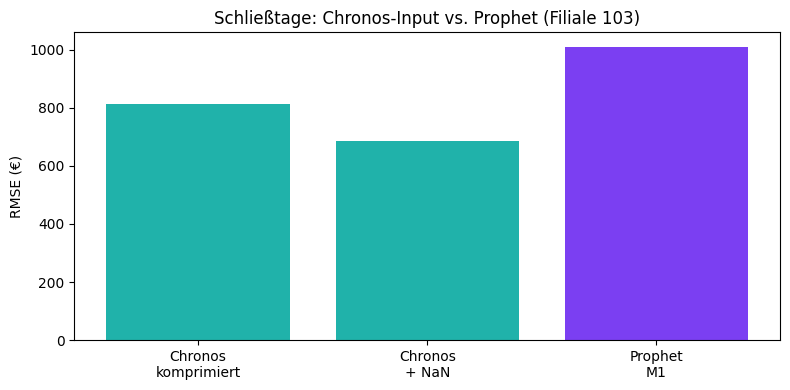

14:31:20 - cmdstanpy - INFO - Chain [1] start processing
14:31:20 - cmdstanpy - INFO - Chain [1] done processing


Prophet M1 (echte ds)            RMSE=  1009.3  MAE=   836.3  MAPE= 18.6%

Vergleich Filiale 103 – gleiche 42 Test-Öffnungstage
                                         RMSE    MAE  MAPE  \
label                                                        
Chronos komprimiert (Schließtage weg)   814.6  638.4  14.3   
Chronos täglich + NaN (Schließtage)     685.3  539.3  11.9   
Prophet M1 (echte ds)                  1009.3  836.3  18.6   

                                                       Kurz  
label                                                        
Chronos komprimiert (Schließtage weg)  Chronos\nkomprimiert  
Chronos täglich + NaN (Schließtage)          Chronos\n+ NaN  
Prophet M1 (echte ds)                           Prophet\nM1  


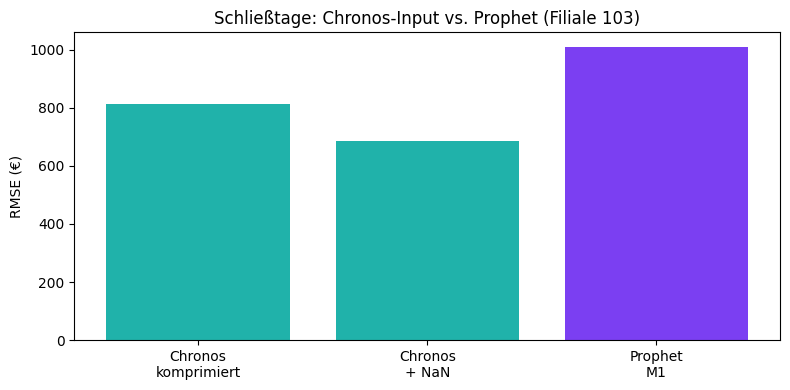

In [5]:
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

STORE_GAPS = 103   # v. a. sonntags geschlossen
H_GAP = H          # gleicher Testhorizont wie oben (42 Öffnungstage)


def gap_summary(store_id, label):
    sub = train[train['Store'] == store_id].sort_values('Date')
    open_days = sub[(sub['Open'] == 1) & (sub['Sales'] > 0)]
    deltas = open_days['Date'].diff().dt.days.dropna()
    closed = (sub['Open'] == 0).sum()
    print(f"{label} (Store {store_id})")
    print(f"  Kalendertage gesamt:     {len(sub)}")
    print(f"  Schließtage (Open=0):    {closed}")
    print(f"  Geöffnete Verkaufstage:  {len(open_days)}")
    print(f"  Anteil Δ=1 Tag:          {(deltas == 1).mean() * 100:.1f}%")
    print(f"  Sprünge > 1 Tag:         {(deltas > 1).sum()} (max {deltas.max():.0f} Tage)")
    return open_days.reset_index(drop=True)


print('── Equidistanz-Check ──')
gap_summary(store, 'Hauptdemo')
print()
open_gaps = gap_summary(STORE_GAPS, 'Schließtage-Vergleich')

# ── Daten für Filiale 103 vorbereiten ───────────────────────────
raw_g = train[train['Store'] == STORE_GAPS].sort_values('Date').reset_index(drop=True)
cal_g = pd.date_range(raw_g['Date'].min(), raw_g['Date'].max(), freq='D')
sales_map = dict(zip(open_gaps['Date'], open_gaps['Sales']))
y_daily = np.array([sales_map.get(d, np.nan) for d in cal_g], dtype=float)

y_comp = open_gaps['Sales'].to_numpy(dtype=float)
y_train_comp, y_test_gap = y_comp[:-H_GAP], y_comp[-H_GAP:]
test_dates_gap = open_gaps['Date'].iloc[-H_GAP:]
test_start = test_dates_gap.iloc[0]
ctx_daily = np.where(cal_g < test_start, y_daily, np.nan)
n_test_cal = int((cal_g >= test_start).sum())

if 'pipe' not in globals():
    pipe = BaseChronosPipeline.from_pretrained('amazon/chronos-bolt-small', device_map='cpu')

# (1) Chronos komprimiert – nur Öffnungstage, implizit equidistant
q_c, _ = pipe.predict_quantiles(
    inputs=torch.tensor(y_train_comp, dtype=torch.float32),
    prediction_length=H_GAP,
    quantile_levels=[0.5],
)
pred_comp = q_c[0, :, 0].numpy()
m_chronos_comp = print_metrics(y_test_gap, pred_comp, 'Chronos komprimiert (Schließtage weg)')

# (2) Chronos täglich – NaN an Schließtagen
q_n, _ = pipe.predict_quantiles(
    inputs=torch.tensor(ctx_daily, dtype=torch.float32),
    prediction_length=n_test_cal,
    quantile_levels=[0.5],
)
pred_cal = q_n[0, :, 0].numpy()
pred_map = dict(zip(cal_g[cal_g >= test_start], pred_cal))
pred_nan = np.array([pred_map[pd.Timestamp(d)] for d in test_dates_gap.values])
m_chronos_nan = print_metrics(y_test_gap, pred_nan, 'Chronos täglich + NaN (Schließtage)')

# (3) Prophet M1 – echte Datumsachse (nur Öffnungstage)
pdf = open_gaps.rename(columns={'Date': 'ds', 'Sales': 'y'})
m_gap = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
m_gap.fit(pdf.iloc[:-H_GAP])
fc_gap = m_gap.predict(pd.DataFrame({'ds': pdf.iloc[-H_GAP:]['ds'].values}))
pred_prophet = fc_gap['yhat'].to_numpy()
m_prophet_gap = print_metrics(y_test_gap, pred_prophet, 'Prophet M1 (echte ds)')

gap_compare = pd.DataFrame([m_chronos_comp, m_chronos_nan, m_prophet_gap])
gap_compare['Kurz'] = ['Chronos\nkomprimiert', 'Chronos\n+ NaN', 'Prophet\nM1']
print('\nVergleich Filiale 103 – gleiche 42 Test-Öffnungstage')
print(gap_compare.set_index('label').round(1))

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#20B2AA', '#20B2AA', '#7B3FF2']  # Chronos = türkis, Prophet = lila
ax.bar(gap_compare['Kurz'], gap_compare['RMSE'], color=colors)
ax.set_ylabel('RMSE (€)')
ax.set_title('Schließtage: Chronos-Input vs. Prophet (Filiale 103)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Was sehen wir?**

- **1097** (Hauptdemo): gefilterte Serie = **täglich equidistant** → Chronos-Input passt zum Kalender.
- **Komprimiert** (Schließtage entfernt): Mo–Fr und Sa–Mo sehen für Chronos wie **ein Schritt** aus → Wochenmuster können verzerrt werden.
- **Täglich + NaN**: markiert fehlende Tage explizit – Chronos Bolt kann `NaN` in der Historie nutzen und behält so **Tages-Raster**.
- **Prophet** kennt ohnehin das Datum (`ds`) und modelliert Wochensaison im Kalender – unabhängig davon, ob du nur Öffnungstage übergibst.

> **Praxis:** Vor Chronos Bolt immer prüfen: Ist die Serie **regelmäßig getaktet**? Wenn nicht → Kalender mit `NaN` auffüllen oder Chronos-2 mit `timestamp` / Prophet mit `ds` nutzen.


---
## 2 · Zero-Shot Baseline (Chronos-Bolt small)

**Der Aha-Moment:** Kein `fit()`, keine Feiertage. Modell laden → Historie rein → Prognose raus.

| | Chronos | Prophet (Parallel) |
|:---|:---|:---|
| Training auf 1097 | **Nein** – vortrainiert | **Ja** – `model.fit()` |
| Kalender / Feiertage | Nein | Ab Modell 2 |
| Input | Zahlenfolge `y_train` | `ds` + `y` mit Datum |

> Chronos sieht Umsätze als **reine Zahlenfolge** (geöffnete Tage hintereinander). Anders als Prophet nutzt es die konkreten Datumswerte nicht – Muster erkennt es allein aus der Sequenz.


In [6]:
# Modell laden (beim 1. Mal Download von Hugging Face -> einmalig Internet nötig)
pipe = BaseChronosPipeline.from_pretrained('amazon/chronos-bolt-small', device_map='cpu')

# Zero-Shot-Vorhersage: nur Historie rein -> Quantile + Mittelwert raus
# Hinweis: das erste Argument heißt in der aktuellen Chronos-Version 'inputs'
quantiles, mean = pipe.predict_quantiles(
    inputs=torch.tensor(y_train, dtype=torch.float32),
    prediction_length=H,
    quantile_levels=[0.1, 0.5, 0.9],
)

# quantiles hat die Form [1, H, 3] -> [Serie, Zeitschritt, Quantil]
lo     = quantiles[0, :, 0].numpy()   # 10%-Quantil (unteres Band)
median = quantiles[0, :, 1].numpy()   # 50%-Quantil (Punktprognose)
hi     = quantiles[0, :, 2].numpy()   # 90%-Quantil (oberes Band)

m_baseline = print_metrics(y_test, median, 'Chronos Bolt-small (zero-shot)')

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

Chronos Bolt-small (zero-shot)   RMSE=  1261.9  MAE=  1042.2  MAPE=  9.6%


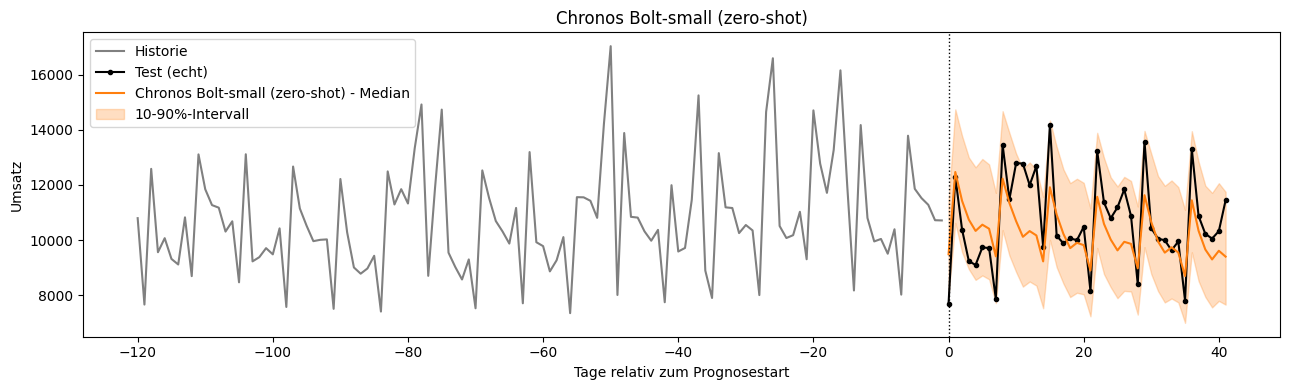

In [7]:
# Plot-Helfer: Ende der Historie + echte Testwerte + Forecast mit 10-90%-Band
def plot_forecast(y_train, y_true, median, lo, hi, label, n_context=120):
    H = len(y_true)
    x_hist = np.arange(-min(n_context, len(y_train)), 0)
    x_fc   = np.arange(0, H)
    plt.figure(figsize=(13, 4))
    plt.plot(x_hist, y_train[-len(x_hist):], color='gray', label='Historie')
    plt.plot(x_fc, y_true, color='black', marker='.', label='Test (echt)')
    plt.plot(x_fc, median, color='C1', label=f'{label} - Median')
    plt.fill_between(x_fc, lo, hi, color='C1', alpha=0.25, label='10-90%-Intervall')
    plt.axvline(0, color='k', ls=':', lw=1)
    plt.title(label)
    plt.xlabel('Tage relativ zum Prognosestart')
    plt.ylabel('Umsatz')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_forecast(y_train, y_test, median, lo, hi, 'Chronos Bolt-small (zero-shot)')

---
## 3 · Hebel 1: Kontextlänge

Bei Prophet haben wir **Feiertage** ergänzt. Bei Chronos ist der wichtigste Stellhebel ohne Zusatzfeatures: **wie viel Historie** das Modell sieht. Wir testen **mehrere Kontextfenster** (letzte *k* Tage) – weiterhin **zero-shot**, nur mit kürzerer/längerer Input-Sequenz.

> **Prophet-Parallel:** Mehr Domänenwissen (Kalender) vs. bei Chronos mehr **Kontext-Tage**.

> Voraussetzung: Abschnitt **2** (Modell `pipe` geladen) – sonst wird es hier nachgeladen.


Kontext = 60 Tage                RMSE=  1553.9  MAE=  1397.8  MAPE= 13.8%
Kontext = 180 Tage               RMSE=  1261.9  MAE=  1102.1  MAPE= 10.6%
Kontext = 365 Tage               RMSE=  1160.5  MAE=   943.6  MAPE=  8.9%
Kontext = 540 Tage               RMSE=  1138.1  MAE=   929.7  MAPE=  8.7%
Kontext = 630 Tage               RMSE=  1139.5  MAE=   930.8  MAPE=  8.7%
Kontext = 900 Tage               RMSE=  1261.9  MAE=  1042.2  MAPE=  9.6%
Kontextfenster vs. RMSE (Filiale 1097, Test = 42 Tage)
                      RMSE     MAE  MAPE  Tage
label                                         
Kontext = 60 Tage   1553.9  1397.8  13.8    60
Kontext = 180 Tage  1261.9  1102.1  10.6   180
Kontext = 365 Tage  1160.5   943.6   8.9   365
Kontext = 540 Tage  1138.1   929.7   8.7   540
Kontext = 630 Tage  1139.5   930.8   8.7   630
Kontext = 900 Tage  1261.9  1042.2   9.6   900


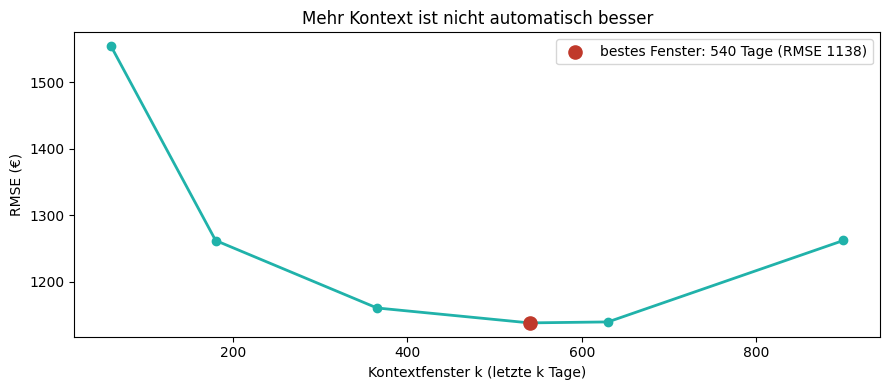

In [8]:
# Mehrere Kontextfenster testen (letzte k Tage von y_train)
CONTEXT_WINDOWS = [60, 180, 365, 540, 630, len(y_train)]

if 'pipe' not in globals():
    pipe = BaseChronosPipeline.from_pretrained('amazon/chronos-bolt-small', device_map='cpu')

results_ctx = []
for k in CONTEXT_WINDOWS:
    ctx = y_train[-k:]
    q, _ = pipe.predict_quantiles(
        inputs=torch.tensor(ctx, dtype=torch.float32),
        prediction_length=H, quantile_levels=[0.1, 0.5, 0.9],
    )
    med = q[0, :, 1].numpy()
    label = f'Kontext = {k} Tage'
    results_ctx.append({**print_metrics(y_test, med, label), 'Tage': k})

ctx_summary = pd.DataFrame(results_ctx).set_index('label')
print('Kontextfenster vs. RMSE (Filiale 1097, Test = 42 Tage)')
print(ctx_summary.round(1))

# Kurve: RMSE über Fensterlänge (zeigt das Optimum)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ctx_summary['Tage'], ctx_summary['RMSE'], marker='o', color='#20B2AA', lw=2)
best = ctx_summary['RMSE'].idxmin()
best_k = int(ctx_summary.loc[best, 'Tage'])
best_rmse = ctx_summary.loc[best, 'RMSE']
ax.scatter([best_k], [best_rmse], color='#C0392B', s=90, zorder=3,
           label=f'bestes Fenster: {best_k} Tage (RMSE {best_rmse:.0f})')
ax.set_xlabel('Kontextfenster k (letzte k Tage)')
ax.set_ylabel('RMSE (€)')
ax.set_title('Mehr Kontext ist nicht automatisch besser')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


**Was sehen wir?**

- **Mehr Kontext ≠ automatisch besser.** Chronos **trainiert nicht** auf Filiale 1097 – längere Historie ist nur mehr Input.
- **60 Tage:** zu wenig Muster → höchste RMSE.
- Die **Kurve** zeigt ein **Optimum** (roter Punkt) – hier meist um **ca. 540 Tage**, nicht bei „so viel wie möglich“.
- **365 Tage** ist schon gut; **630** oft ähnlich; **900 (= volles `y_train`)** wird wieder **schlechter**.
- **Warum 900 schlechter?** **Trend:** ältere Umsätze (2013/14, Ø ca. 9 100 €) liegen unter dem Niveau von 2015 (ca. 10 200 €) und ziehen die zero-shot-Prognose vom aktuellen Level weg.

> **Merke:** Kontextlänge ist ein **Drehregler** – mehrere *k* testen und das **Minimum in der Kurve** wählen, nicht blind `len(y_train)`.


---
## 4 · Hebel 2: Modellgröße

### Chronos-Modelle im Überblick

In dieser Demo nutzen wir **Chronos-Bolt** (Abschnitte 2–4) und **Chronos-2** (Abschnitt 5). Alle sind **vortrainiert** – zero-shot, kein `fit()` auf Rossmann.

| Modell (Hugging Face) | Familie | Parameter | Eingabe | Kovariaten | max. Kontext | max. Horizont | In der Demo |
|:---|:---|---:|:---|:---:|---:|---:|:---|
| `amazon/chronos-bolt-tiny` | **Bolt** | 9M | Zahlensequenz (`inputs`) | nein | 2048 | 64 | Abschnitt **4** |
| `amazon/chronos-bolt-small` | **Bolt** | 48M | Zahlensequenz | nein | 2048 | 64 | Abschnitte **2**, **3** |
| `amazon/chronos-bolt-base` | **Bolt** | 205M | Zahlensequenz | nein | 2048 | 64 | Abschnitte **4**, **8** |
| `amazon/chronos-2` | **Chronos-2** | 120M | `DataFrame` + `timestamp` | **ja** (z. B. Promo) | 8192 | 1024 | Abschnitte **5**, **8** |

> **Nicht in dieser Demo:** die ältere **Chronos-T5**-Linie (`chronos-t5-small/base/large`, max. Kontext **512**, langsamer) – optional in `chronosTest.ipynb`.

**Was ist der Unterschied?**

| | **Chronos-Bolt** | **Chronos-2** |
|:---|:---|:---|
| **Architektur** | Patch-basiert, direkte Multi-Step-Prognose → **sehr schnell** | Encoder-Foundation-Model, Gruppen-Attention |
| **Typischer Input** | Nur Historie als Tensor – **kein Kalender** | Historie + **bekannte Zukunfts-Kovariaten** (`future_df`) |
| **Multivariat** | nein (eine Serie) | ja (mehrere Serien / Items möglich) |
| **Stärke** | Schnelles zero-shot für viele Reihen | Domänenwissen wie Prophet-Regressoren (Promo, Events) |
| **Pipeline** | `BaseChronosPipeline` | `Chronos2Pipeline` |

---

Gegenstück zu Prophets „regionale Feiertage / Zeitfenster": mehr **Modell-Power** (Bolt-Größe) statt Feature-Engineering. Unten vergleichen wir `bolt-tiny` → `bolt-small` → `bolt-base` – jeweils nur **Inferenz**.

> Für den **fairen Vergleich in Abschnitt 8** merken: **bolt-base** (nicht bolt-small). Mit Kovariaten: **Chronos-2** (Abschnitt 5).


In [9]:
results_size = []
for model_id in ['amazon/chronos-bolt-tiny', 'amazon/chronos-bolt-small', 'amazon/chronos-bolt-base']:
    p = BaseChronosPipeline.from_pretrained(model_id, device_map='cpu')
    t0 = time.time()
    q, _ = p.predict_quantiles(
        inputs=torch.tensor(y_train, dtype=torch.float32),
        prediction_length=H, quantile_levels=[0.1, 0.5, 0.9],
    )
    dt = time.time() - t0
    med = q[0, :, 1].numpy()
    r = print_metrics(y_test, med, model_id.split('/')[-1])
    r['Sekunden'] = round(dt, 2)
    results_size.append(r)

pd.DataFrame(results_size).set_index('label').round(1)

Loading weights:   0%|          | 0/101 [00:00<?, ?it/s]

chronos-bolt-tiny                RMSE=  1650.2  MAE=  1321.8  MAPE= 12.4%


Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

chronos-bolt-small               RMSE=  1261.9  MAE=  1042.2  MAPE=  9.6%


Loading weights:   0%|          | 0/269 [00:00<?, ?it/s]

chronos-bolt-base                RMSE=  1029.7  MAE=   824.7  MAPE=  7.6%


,RMSE,MAE,MAPE,Sekunden
label,,,,
chronos-bolt-tiny,1650.2,1321.8,12.4,0.0
chronos-bolt-small,1261.9,1042.2,9.6,0.1
chronos-bolt-base,1029.7,824.7,7.6,0.3


---
## 5 · Hebel 3: Kovariate „Promo" (Chronos-2)

**Direktes Gegenstück zum Prophet-Regressor.** Chronos-2 kann zusätzliche Einflussgrößen (hier: `Promo`) als Kovariate nutzen – inkl. der *zukünftigen* (bekannten) Promo-Werte über `future_df`. Das geht mit **Chronos-Bolt nicht** (siehe Modelltabelle in **Abschnitt 4**).

> Für den **Experten-Vergleich in Abschnitt 8** diesen Block mit ausführen. Beim ersten Mal ~250 MB Download (`amazon/chronos-2`, `pandas[pyarrow]`).


In [10]:
from chronos import Chronos2Pipeline

pipe2 = Chronos2Pipeline.from_pretrained('amazon/chronos-2', device_map='cpu')

# Vergangenheit: Datum, Ziel (Sales) und die Kovariate Promo
context_df = pd.DataFrame({
    'id': 'store_1097',
    'timestamp': dates_train.values,
    'target': y_train,
    'Promo': df['Promo'].to_numpy()[:-H],
})
# Zukunft: künftige Zeitpunkte + bekannte Promo-Werte, OHNE target
future_df = pd.DataFrame({
    'id': 'store_1097',
    'timestamp': dates_test.values,
    'Promo': df['Promo'].to_numpy()[-H:],
})

pred_df = pipe2.predict_df(
    context_df, future_df=future_df,
    prediction_length=H, quantile_levels=[0.1, 0.5, 0.9],
    id_column='id', timestamp_column='timestamp', target='target',
)

# Median-Spalte heißt '0.5', Punktprognose 'predictions'
med2 = pred_df['0.5'].to_numpy()
m_cov = print_metrics(y_test, med2, 'Chronos-2 + Promo (Kovariate)')

Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Chronos-2 + Promo (Kovariate)    RMSE=   703.0  MAE=   532.1  MAPE=  4.8%


---
## 6 · Unsicherheit: Prognoseintervalle

Chronos ist **probabilistisch**: Es liefert Quantile, nicht nur einen Wert. Wir prüfen, wie gut das 10-90%-Band die echten Werte abdeckt (Soll: ~80%).

Abdeckung 10-90%-Band: 93% der Testwerte liegen im Band
Mittlere Bandbreite: 4158 Umsatz-Einheiten


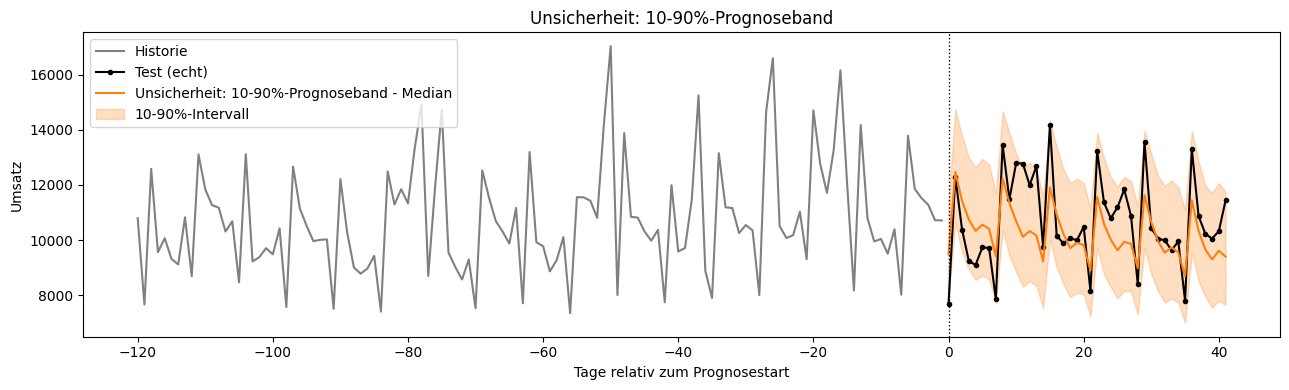

In [11]:
inside = (y_test >= lo) & (y_test <= hi)
print(f'Abdeckung 10-90%-Band: {inside.mean()*100:.0f}% der Testwerte liegen im Band')
print(f'Mittlere Bandbreite: {np.mean(hi - lo):.0f} Umsatz-Einheiten')
plot_forecast(y_train, y_test, median, lo, hi, 'Unsicherheit: 10-90%-Prognoseband')

---
## 6b · Chronos-Vorteil: Cold Start (wenig Historie)

Hier spielt Chronos seine Stärke aus: Wir tun so, als wäre 1097 eine **neue Filiale** mit nur 60 Tagen Historie. Prophet kann mit so wenig Daten die Jahressaison kaum lernen – Chronos bringt **Pretraining-Wissen** mit und sagt trotzdem sinnvoll vorher.

Als faire Messlatte *ohne* Vorwissen nehmen wir **Seasonal Naive** (letzte Woche wiederholen). Erwartung: Chronos schlägt es deutlich, obwohl beide gleich wenig Historie sehen.

> **Verbindung zu Abschnitt 8:** Seasonal Naive rechnen wir dort noch einmal auf der **vollen** Historie – gleiche Idee, anderer Kontext.

> **Präsentation:** Dieselben 60 Tage auch in Prophet füttern – Prophet trifft die Saison kaum. Das ist der überzeugendste „Chronos gewinnt"-Moment.


Chronos (nur 60 Tage Kontext)    RMSE=  1553.9  MAE=  1397.8  MAPE= 13.8%
Seasonal-Naive (letzte Woche)    RMSE=  1116.1  MAE=   942.0  MAPE=  9.0%


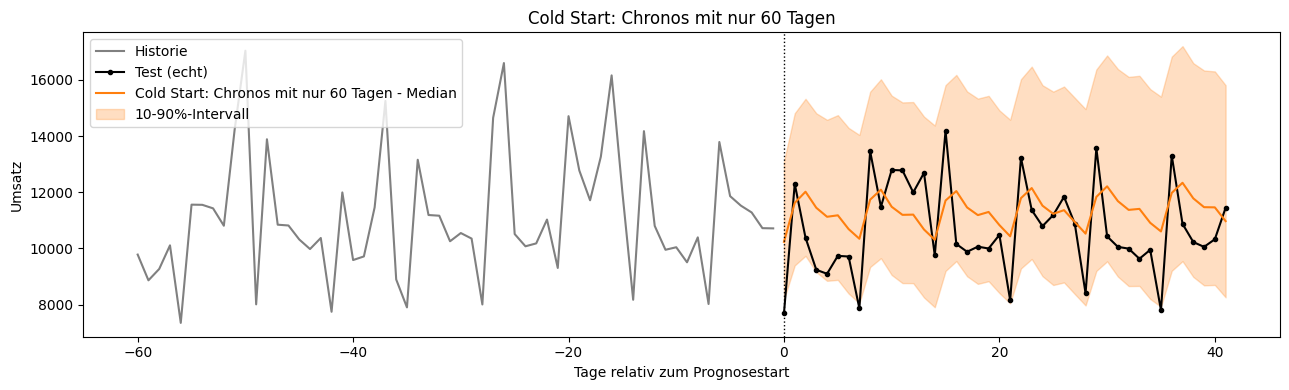

In [12]:
# 'Neue Filiale': nur die letzten 60 Tage als Historie verfügbar
short_ctx = 60
y_short = y_train[-short_ctx:]

# (a) Chronos zero-shot mit wenig Historie
q, _ = pipe.predict_quantiles(
    inputs=torch.tensor(y_short, dtype=torch.float32),
    prediction_length=H, quantile_levels=[0.1, 0.5, 0.9],
)
med_cold = q[0, :, 1].numpy(); lo_cold = q[0, :, 0].numpy(); hi_cold = q[0, :, 2].numpy()

# (b) Vergleich ohne Vorwissen: Seasonal-Naive (letzte Woche wiederholen)
season = 7
naive = np.array([y_short[-season + (i % season)] for i in range(H)])

print_metrics(y_test, med_cold, f'Chronos (nur {short_ctx} Tage Kontext)')
print_metrics(y_test, naive,    'Seasonal-Naive (letzte Woche)')
plot_forecast(y_short, y_test, med_cold, lo_cold, hi_cold, f'Cold Start: Chronos mit nur {short_ctx} Tagen')

---
## 7 · 🦢 Black-Swan-Stresstest (Flugdaten)

Gleicher Stresstest wie bei Prophet: Wie reagiert ein Foundation Model auf einen plötzlichen Strukturbruch (Corona-Einbruch im Flugverkehr)? Sieht Chronos den Crash kommen – oder extrapoliert es nur die gelernte Saisonalität?

> Wichtig fürs Fazit: Einen echten Black Swan kann **kein** Modell vorhersehen – Prophet so wenig wie Chronos. Dieser Test zeigt die Grenze *beider* Verfahren, nicht einen Chronos-Nachteil.

C:\Users\kaiws\anaconda3\envs\ts-tutorial\lib\site-packages\chronos\chronos_bolt.py:546: UserWarning: We recommend keeping prediction length <= 64. The quality of longer predictions may degrade since the model is not optimized for it. 
  warnings.warn(msg)


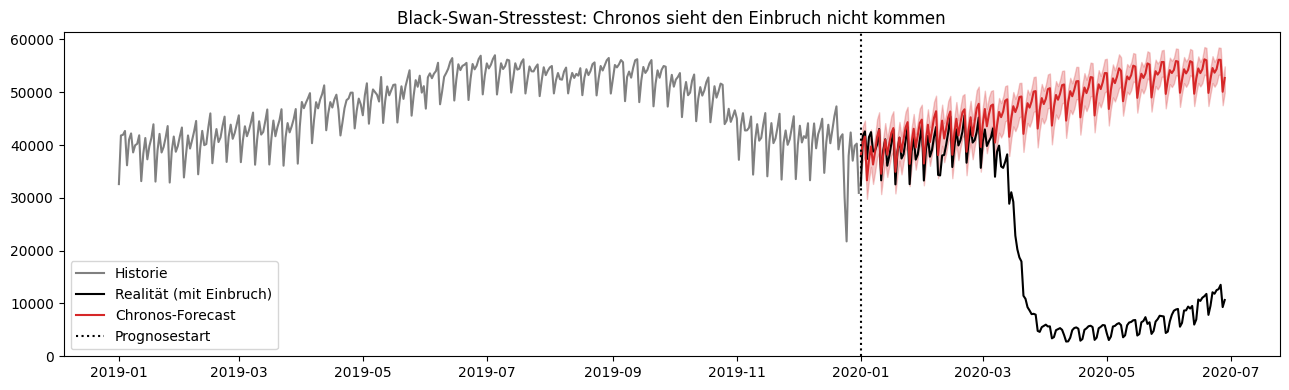

In [13]:
df_flights = pd.read_csv('../data/flights.csv', parse_dates=['FLT_DATE'])
daily = df_flights.groupby('FLT_DATE')['FLT_TOT_1'].sum().sort_index()
# Zeitzone entfernen, falls vorhanden (sonst Vergleich mit tz-naivem Timestamp -> Fehler)
if daily.index.tz is not None:
    daily.index = daily.index.tz_localize(None)
y_f = daily.to_numpy(dtype=float)

# Kontext: alles VOR dem Bruch (Anfang 2020). Forecast über den Bruch hinweg.
cut = daily.index.get_indexer([pd.Timestamp('2020-01-01')], method='nearest')[0]
Hf = 180  # ~6 Monate vorhersagen
ctx_f  = y_f[:cut]
true_f = y_f[cut:cut + Hf]

q, _ = pipe.predict_quantiles(
    inputs=torch.tensor(ctx_f, dtype=torch.float32),
    prediction_length=Hf, quantile_levels=[0.1, 0.5, 0.9],
)
med_f = q[0, :, 1].numpy(); lo_f = q[0, :, 0].numpy(); hi_f = q[0, :, 2].numpy()

start = max(0, cut - 365)
plt.figure(figsize=(13, 4))
plt.plot(daily.index[start:cut], y_f[start:cut], color='gray', label='Historie')
plt.plot(daily.index[cut:cut + Hf], true_f, color='black', label='Realität (mit Einbruch)')
plt.plot(daily.index[cut:cut + Hf], med_f, color='C3', label='Chronos-Forecast')
plt.fill_between(daily.index[cut:cut + Hf], lo_f, hi_f, color='C3', alpha=0.25)
plt.axvline(daily.index[cut], color='k', ls=':', label='Prognosestart')
plt.title('Black-Swan-Stresstest: Chronos sieht den Einbruch nicht kommen')
plt.legend(); plt.tight_layout(); plt.show()

---
## 8 · Fazit: Chronos vs. klassische Modelle & Prophet

**Lernziel:** Einordnen, wo Chronos gegenüber **einfachen Klassikern** und **Prophet mit Domänenwissen** steht – nicht nur „wer gewinnt?", sondern **unter welchen Bedingungen**.

**Voraussetzung:** Abschnitte **0–5** ausführen (liefert `chronos_summary`, optional `m_cov` für 8.4). Abschnitte 6–7 sind optional, aber gut für die Diskussion.

1. **8.1** – Chronos-Varianten + **klassische Baselines** (Naive, Seasonal Naive, linearer Trend)
2. **8.2** – **Gesamtüberblick** – alle Ansätze auf einem Blick
3. **8.3** – **Fairer** Vergleich ohne Zusatzwissen (Klassik vs. Chronos vs. Prophet M1) – *in der Demo zuerst zeigen*
4. **8.4** – Weitere Vergleiche (Experte, unfair, Prophet-Stufen)

Farben: **Chronos = türkis** · **Prophet = lila** · **Klassisch = grau**


### 8.1 · Chronos & klassische Baselines

**Klassische Modelle** (ohne Feiertagskalender, ohne Foundation-Model-Pretraining) – **kein ARIMA/SARIMA**, sondern bewusst einfache, sofort nachvollziehbare Baselines:

| Baseline | Idee | Training? |
|:---|:---|:---|
| **Naive** | Letzter Wert wird wiederholt | Nein |
| **Seasonal Naive (7d)** | Letzte Woche tageweise wiederholt | Nein |
| **Linearer Trend** | Lineare Regression (`sklearn`) auf der Zeitachse | Ja – nur diese Zeile nutzt `.fit()` |

**Ausgangslage (wie im gesamten Notebook):**

- `y_train` = alle Tage **bis** zum Testfenster (hier ca. 900 Tage Historie)
- `y_test` = die **42 Tage**, die wir vorhersagen wollen (RMSE/MAPE werden nur hier gemessen)
- `H = len(y_test) = 42`

Die Baselines kennen **nur** `y_train`. Sie „sehen“ `y_test` nicht – genau wie Chronos zero-shot.

---

#### 1 · Naive (Last-Value-Forecast)

**Regel:** Prognose für **jeden** zukünftigen Tag = **letzter bekannter Umsatz**.

Formel für Testtag \(t = 1, \ldots, H\) (1 = erster Tag nach Ende von `y_train`):

\[
\hat{y}_t = y_{\text{Train, letzter}} = \texttt{y\_train[-1]}
\]

**Im Code:** `naive_full = np.full(H, y_train[-1])` → ein konstantes Array mit 42× demselben Wert.

**Intuition:** „Morgen sieht aus wie gestern.“ Kein Trend, keine Wochensaison – nur das Niveau am Ende der Historie.

**Schwäche bei Rossmann:** Ignoriert Wochentagseffekte (Mo vs. Sa) und Promo/Feiertage → oft schlechte RMSE.

---

#### 2 · Seasonal Naive (7 Tage)

**Regel:** Prognose für Testtag \(t\) = Umsatz vom **gleichen Wochentag in der letzten vollständigen Woche** der Historie.

Mit Saisonlänge `season = 7` und Index \(i = 0, \ldots, H-1\) für den \(i\)-ten Testtag:

\[
\hat{y}_t = \texttt{y\_train[-7 + (i mod 7)]}
\]

**Beispiel** (letzte 7 Trainingswerte = Mo–So der letzten Woche):

| Testtag \(i\) | Kalendertag | genutzt aus `y_train` | Bedeutung |
|:---:|:---|:---|:---|
| 0 | 1. Testtag (Mo) | `y_train[-7]` | Umsatz vom **Mo** der Vorwoche |
| 1 | Di | `y_train[-6]` | Di der Vorwoche |
| … | … | … | … |
| 6 | So | `y_train[-1]` | **Letzter** Trainingswert (So) |
| 7 | Mo (Woche 2) | `y_train[-7]` | wieder Mo der Vorwoche |

**Im Code:** `naive_seasonal = np.array([y_train[-season + (i % season)] for i in range(H)])`

**Intuition:** „Diese Woche wiederholt sich die **letzte Woche** tageweise.“ Das ist die **Standard-Baseline** bei täglichen Daten mit Wochensaison – oft überraschend stark.

**Was fehlt:** Kein Trend (steigende Umsätze), keine Feiertage, keine Promo – nur 7-Tage-Muster.

---

#### 3 · Linearer Trend

**Regel:** Zuerst eine **Gerade** durch die Trainingshistorie legen, dann die Gerade **linear weiterziehen**.

Zeitindex \(t = 0, 1, \ldots, n-1\) für die \(n\) Trainingstage (`n = len(y_train)`). Modell:

\[
y_t \approx a + b \cdot t
\]

**Schritt 1 – fit (nur auf `y_train`):**

- `X_tr = [0, 1, 2, …, n-1]` (Spaltenvektor)
- `LinearRegression().fit(X_tr, y_train)` schätzt \(a\) (Achsenabschnitt) und \(b\) (Tagestrend in €)

**Schritt 2 – forecast (42 Testtage):**

- `X_te = [n, n+1, …, n+H-1]` → Indizes **direkt hinter** dem letzten Trainingstag
- `predict(X_te)` liefert \(\hat{y} = a + b \cdot t\) für jeden Testtag

**Intuition:** „Der langfristige Anstieg/Fall der Filiale setzt sich linear fort.“ Erfasst **Trend**, aber **keine** Wochensaison (Mo/So gleich behandelt).

**Schwäche bei Rossmann:** Retail-Umsätze sind stark wochen- und kalendergetrieben – reine Gerade verfehlt das oft trotz `.fit()`.

---

**Chronos-Werte** kommen aus Abschnitt **2–5** (nur **Inferenz**, kein `fit()` auf Rossmann). Hier fassen wir alles zusammen.

> Solche Baselines sind in der Literatur oft **stärker als erwartet** – immer mitdenken, bevor man „fancy" Modelle feiert.


In [14]:
from sklearn.linear_model import LinearRegression

CHRONOS_COLOR = '#20B2AA'
PROPHET_COLOR = '#7B3FF2'
CLASSIC_COLOR = '#95A5A6'

# ── Chronos-Varianten ───────────────────────────────────────────
chronos_rows = [m_baseline] + results_size
if 'm_cov' in globals():
    chronos_rows.append(m_cov)
chronos_summary = (
    pd.DataFrame(chronos_rows).drop_duplicates('label').set_index('label')
)
chronos_base_rmse = chronos_summary.loc['chronos-bolt-base', 'RMSE']
chronos_base_mape = chronos_summary.loc['chronos-bolt-base', 'MAPE']

# ── Klassische Baselines (gleicher Test wie oben) ───────────────
H = len(y_test)
season = 7
naive_full = np.full(H, y_train[-1])
naive_seasonal = np.array([y_train[-season + (i % season)] for i in range(H)])
X_tr = np.arange(len(y_train)).reshape(-1, 1)
X_te = np.arange(len(y_train), len(y_train) + H).reshape(-1, 1)
lin_trend = LinearRegression().fit(X_tr, y_train).predict(X_te)

m_naive = print_metrics(y_test, naive_full, 'Klassisch: Naive')
m_snaive = print_metrics(y_test, naive_seasonal, 'Klassisch: Seasonal Naive (7d)')
m_lin = print_metrics(y_test, lin_trend, 'Klassisch: Linearer Trend')
classical_summary = pd.DataFrame([m_naive, m_snaive, m_lin]).set_index('label')

print('\nChronos-Varianten')
print(chronos_summary.round(1))
print('\nKlassische Baselines')
print(classical_summary.round(1))


def plot_pairwise(groups, left_col='Chronos RMSE', right_col='Prophet RMSE', title='',
                  left_label='Chronos', right_label='Prophet',
                  left_color=CHRONOS_COLOR, right_color=PROPHET_COLOR):
    """Zwei-Wege-Vergleich: Chronos links, Prophet rechts."""
    x = np.arange(len(groups))
    w = 0.35
    fig, ax = plt.subplots(figsize=(9, 4))
    l_vals = groups[left_col].to_numpy()
    r_vals = groups[right_col].to_numpy()
    ax.bar(x - w / 2, l_vals, w, label=left_label, color=left_color)
    ax.bar(x + w / 2, r_vals, w, label=right_label, color=right_color)
    ax.set_xticks(x, groups.index, rotation=0)
    ax.set_ylabel('RMSE (€)')
    ax.set_title(title)
    ax.legend(loc='upper right')
    ymax = max(l_vals.max(), r_vals.max())
    for i, (lv, rv) in enumerate(zip(l_vals, r_vals)):
        ax.text(i - w / 2, lv + ymax * 0.02, f'{lv:.0f}', ha='center', fontsize=9, color=left_color)
        ax.text(i + w / 2, rv + ymax * 0.02, f'{rv:.0f}', ha='center', fontsize=9, color=right_color)
    plt.tight_layout()
    plt.show()


Klassisch: Naive                 RMSE=  1630.9  MAE=  1319.1  MAPE= 12.7%
Klassisch: Seasonal Naive (7d)   RMSE=  1116.1  MAE=   942.0  MAPE=  9.0%
Klassisch: Linearer Trend        RMSE=  1633.3  MAE=  1329.9  MAPE= 12.8%

Chronos-Varianten
                                  RMSE     MAE  MAPE  Sekunden
label                                                         
Chronos Bolt-small (zero-shot)  1261.9  1042.2   9.6       NaN
chronos-bolt-tiny               1650.2  1321.8  12.4       0.0
chronos-bolt-small              1261.9  1042.2   9.6       0.1
chronos-bolt-base               1029.7   824.7   7.6       0.3
Chronos-2 + Promo (Kovariate)    703.0   532.1   4.8       NaN

Klassische Baselines
                                  RMSE     MAE  MAPE
label                                               
Klassisch: Naive                1630.9  1319.1  12.7
Klassisch: Seasonal Naive (7d)  1116.1   942.0   9.0
Klassisch: Linearer Trend       1633.3  1329.9  12.8


### 8.2 · Gesamtüberblick: alle Ansätze

Sortiert nach RMSE – so seht ihr auf einen Blick, wo **Klassik**, **Chronos** und **Prophet** liegen.


Gesamtüberblick (Filiale 1097, Test = 42 Tage)
                        Modell   Familie   RMSE  MAPE
           Prophet M5: + Promo   Prophet  645.0   4.7
 Chronos-2 + Promo (Kovariate)   Chronos  703.0   4.8
     Prophet M4: + Zeitfenster   Prophet  816.0   6.3
             chronos-bolt-base   Chronos 1029.7   7.6
    Prophet M3: + NRW/Karneval   Prophet 1032.0   7.3
       Prophet M2: + Feiertage   Prophet 1095.0   7.6
Klassisch: Seasonal Naive (7d) Klassisch 1116.1   9.0
Chronos Bolt-small (zero-shot)   Chronos 1261.9   9.6
            chronos-bolt-small   Chronos 1261.9   9.6
          Prophet M1: Baseline   Prophet 1353.0   8.8
              Klassisch: Naive Klassisch 1630.9  12.7
     Klassisch: Linearer Trend Klassisch 1633.3  12.8
             chronos-bolt-tiny   Chronos 1650.2  12.4


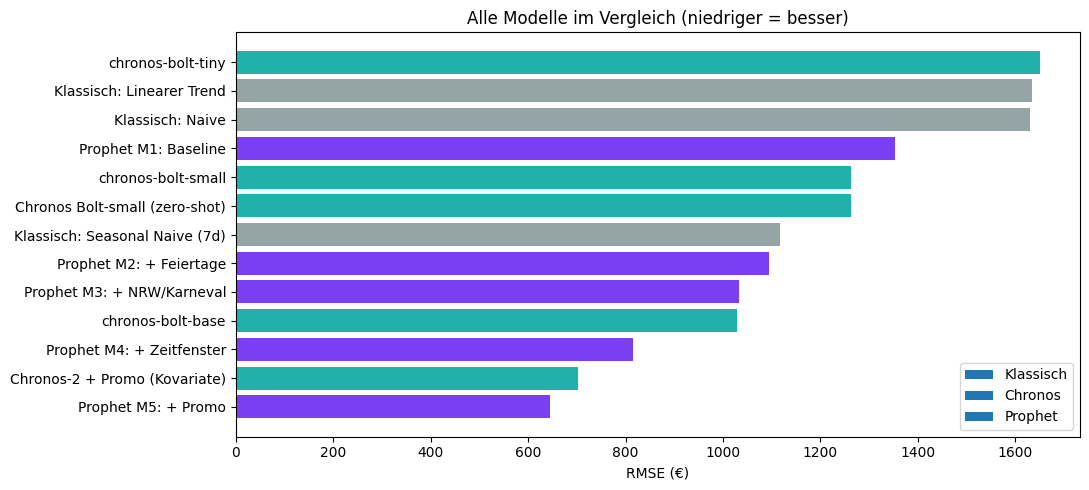

In [15]:
landscape_rows = []
for label, row in classical_summary.iterrows():
    landscape_rows.append({'Modell': label, 'Familie': 'Klassisch', 'RMSE': row['RMSE'], 'MAPE': row['MAPE']})
for label, row in chronos_summary.iterrows():
    landscape_rows.append({'Modell': label, 'Familie': 'Chronos', 'RMSE': row['RMSE'], 'MAPE': row['MAPE']})
prophet_landscape = [
    ('Prophet M1: Baseline', 1353, 8.8),
    ('Prophet M2: + Feiertage', 1095, 7.6),
    ('Prophet M3: + NRW/Karneval', 1032, 7.3),
    ('Prophet M4: + Zeitfenster', 816, 6.3),
    ('Prophet M5: + Promo', 645, 4.7),
]
for name, rmse, mape in prophet_landscape:
    landscape_rows.append({'Modell': name, 'Familie': 'Prophet', 'RMSE': rmse, 'MAPE': mape})

landscape = pd.DataFrame(landscape_rows).sort_values('RMSE').reset_index(drop=True)
print('Gesamtüberblick (Filiale 1097, Test = 42 Tage)')
print(landscape.round(1).to_string(index=False))

palette = {'Klassisch': CLASSIC_COLOR, 'Chronos': CHRONOS_COLOR, 'Prophet': PROPHET_COLOR}
fig, ax = plt.subplots(figsize=(11, max(5, 0.35 * len(landscape))))
colors = landscape['Familie'].map(palette)
ax.barh(landscape['Modell'], landscape['RMSE'], color=colors)
ax.set_xlabel('RMSE (€)')
ax.set_title('Alle Modelle im Vergleich (niedriger = besser)')
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=col, edgecolor=col, label=fam) for fam, col in palette.items()]
ax.legend(handles=legend_handles, loc='lower right')
plt.tight_layout()
plt.show()

best_classic_rmse = classical_summary['RMSE'].min()
best_classic_label = classical_summary['RMSE'].idxmin()


**Was sehen wir?** Oft schlägt **Seasonal Naive** schon naive Chronos-Varianten – deshalb immer **Klassiker mitdenken**, bevor man Foundation Models oder Prophet als „Sieger" feiert.


### 8.3 · Fairer Vergleich ohne Zusatzwissen (zuerst!)

Drei **faire** Baselines auf gleichem Wissensstand (kein Kalender, keine Promo, keine Feiertage):

- bester **Klassiker** (hier meist Seasonal Naive)
- **Chronos bolt-base** zero-shot
- **Prophet Modell 1** (Trend + Saisonalität)


                               Links  Links RMSE              Mitte  \
Vergleich                                                             
Fair · Baseline  Seasonal Naive (7d)      1116.1  Chronos bolt-base   

                 Mitte RMSE      Rechts  Rechts RMSE  
Vergleich                                             
Fair · Baseline      1029.7  Prophet M1         1353  


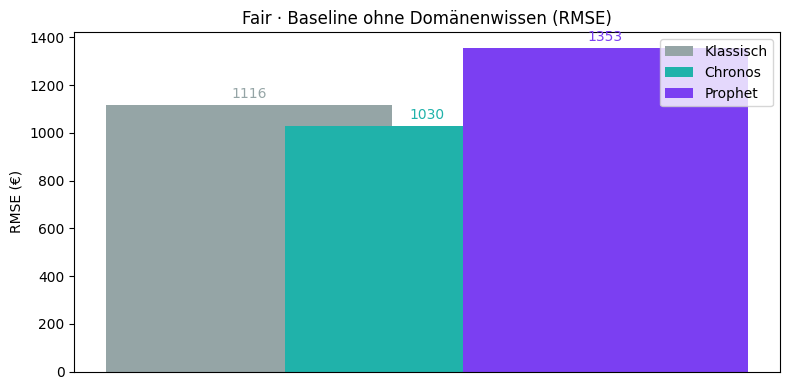

In [16]:
fair_baseline = pd.DataFrame([
    {
        'Vergleich': 'Fair · Baseline',
        'Links': best_classic_label.replace('Klassisch: ', ''),
        'Links RMSE': classical_summary.loc[best_classic_label, 'RMSE'],
        'Mitte': 'Chronos bolt-base',
        'Mitte RMSE': chronos_base_rmse,
        'Rechts': 'Prophet M1',
        'Rechts RMSE': 1353,
    },
]).set_index('Vergleich')
print(fair_baseline.round(1))

x = np.arange(1)
w = 0.25
fig, ax = plt.subplots(figsize=(8, 4))
vals = [
    classical_summary.loc[best_classic_label, 'RMSE'],
    chronos_base_rmse,
    1353,
]
labels = ['Klassisch\n(best)', 'Chronos\nbolt-base', 'Prophet\nM1']
cols = [CLASSIC_COLOR, CHRONOS_COLOR, PROPHET_COLOR]
offsets = [-w, 0, w]
for off, val, lab, col in zip(offsets, vals, labels, cols):
    ax.bar(off, val, w * 1.6, label=lab.split('\n')[0], color=col)
    ax.text(off, val + 30, f'{val:.0f}', ha='center', fontsize=10, color=col)
ax.set_xticks([])
ax.set_ylabel('RMSE (€)')
ax.set_title('Fair · Baseline ohne Domänenwissen (RMSE)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()


**Was sehen wir?** Auf gleichem Wissensstand liegen **Klassik**, **Chronos bolt-base** und **Prophet M1** oft in ähnlicher Größenordnung. Chronos ist hier nicht „schlecht" – es liefert zero-shot vergleichbare Baseline-Qualität **ohne** `fit()` und ohne Kalender-Setup.

### 8.4 · Weitere Vergleiche (Prophet mit Domänenwissen)

Jetzt erst Stufen mit **mehr Wissen** – und abschließend der **unfaire** Vergleich (bewusst unterschiedlicher Informationsstand).

> Fehlt `m_cov`? → Abschnitt **5** ausführen; sonst erscheint nur ein Hinweis statt Abbruch.


Fair · Experte (Chronos links, Prophet rechts)


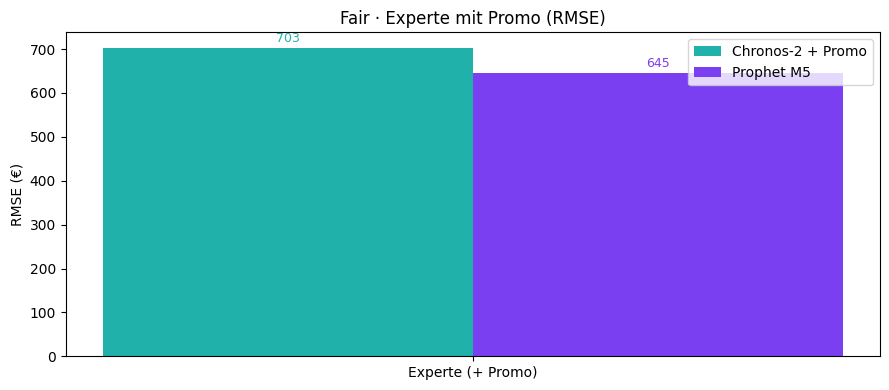


Unfair · Chronos zero-shot vs. Prophet voll ausgebaut


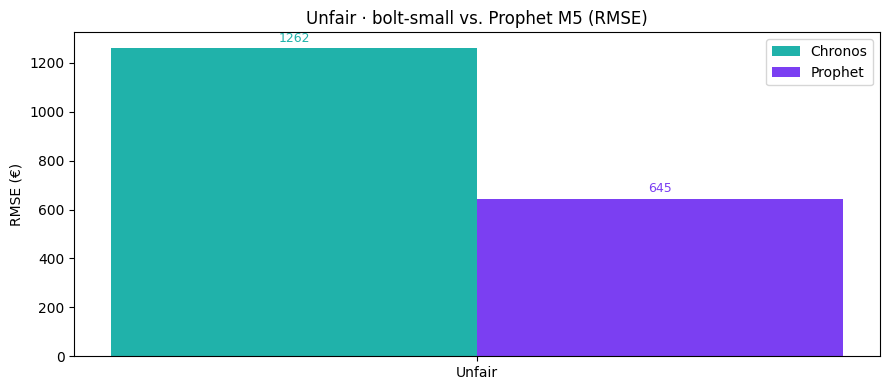

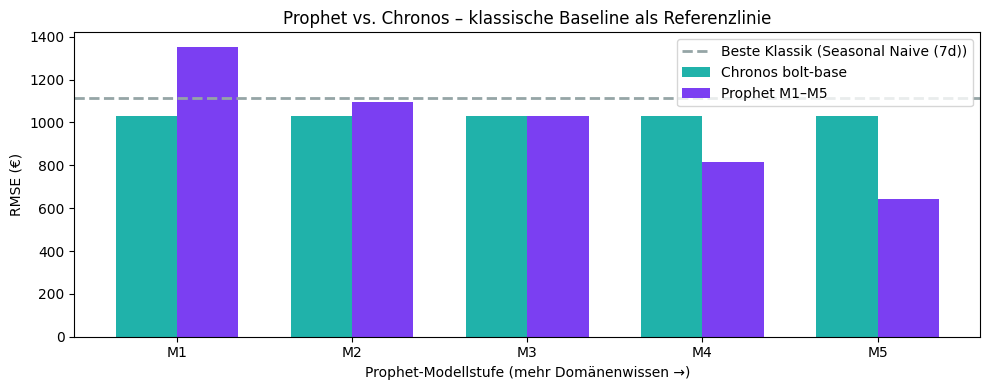

In [17]:
prophet_ref = pd.DataFrame([
    {'label': 'Prophet 1: Baseline (Trend+Saison)', 'RMSE': 1353, 'MAPE': 8.8},
    {'label': 'Prophet 2: + bundesweite Feiertage', 'RMSE': 1095, 'MAPE': 7.6},
    {'label': 'Prophet 3: + NRW + Karneval', 'RMSE': 1032, 'MAPE': 7.3},
    {'label': 'Prophet 4: + Zeitfenster', 'RMSE': 816, 'MAPE': 6.3},
    {'label': 'Prophet 5: + Promo (Final)', 'RMSE': 645, 'MAPE': 4.7},
]).set_index('label')

if 'm_cov' in globals():
    experte = pd.DataFrame([
        {
            'Stufe': 'Experte (+ Promo)',
            'Chronos RMSE': m_cov['RMSE'],
            'Prophet RMSE': 645,
        },
    ]).set_index('Stufe')
    print('Fair · Experte (Chronos links, Prophet rechts)')
    plot_pairwise(experte, title='Fair · Experte mit Promo (RMSE)',
                  left_label='Chronos-2 + Promo', right_label='Prophet M5')
else:
    print('(Abschnitt 5 ausführen für Experten-Vergleich Chronos-2 + Promo.)')

unfair = pd.DataFrame([
    {
        'Stufe': 'Unfair',
        'Chronos RMSE': chronos_summary.loc['chronos-bolt-small', 'RMSE'],
        'Prophet RMSE': 645,
    },
]).set_index('Stufe')
print('\nUnfair · Chronos zero-shot vs. Prophet voll ausgebaut')
plot_pairwise(unfair, title='Unfair · bolt-small vs. Prophet M5 (RMSE)')

x = np.arange(len(prophet_ref))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - w / 2, [chronos_base_rmse] * len(x), w, label='Chronos bolt-base', color=CHRONOS_COLOR)
ax.bar(x + w / 2, prophet_ref['RMSE'], w, label='Prophet M1–M5', color=PROPHET_COLOR)
ax.axhline(classical_summary.loc[best_classic_label, 'RMSE'], color=CLASSIC_COLOR,
           ls='--', lw=2, label=f'Beste Klassik ({best_classic_label.replace("Klassisch: ", "")})')
ax.set_xticks(x, [f'M{i}' for i in range(1, 6)])
ax.set_xlabel('Prophet-Modellstufe (mehr Domänenwissen →)')
ax.set_ylabel('RMSE (€)')
ax.set_title('Prophet vs. Chronos – klassische Baseline als Referenzlinie')
ax.legend()
plt.tight_layout()
plt.show()


**Takeaway**

- **Klassisch:** Seasonal Naive & Co. sind ernst zu nehmende Baselines – oft besser als „fancy" zero-shot.
- **Chronos:** Kein Training auf euren Daten – **Pretraining + Inferenz**. Stark bei wenig Setup; bolt-base ≈ Prophet M1.
- **Prophet:** Gewinnt, wenn **Domänenwissen** (Karneval, Promo, Feiertage) eingebaut wird (`fit` pro Serie).
- **Unfair vergleichen** (Chronos zero-shot vs. Prophet M5) überschätzt Prophet systematisch.

**Merke für die Präsentation:** Der große Abstand entsteht vor allem, wenn man Chronos *bolt-small* (ohne Kalender) mit Prophet *Modell 5* (Feiertage + Karneval + Promo) vergleicht. Der **faire** Vergleich in 8.3 zeigt: Chronos bekommt schlicht **weniger Information** – bis man Kovariaten nachzieht (Abschnitt 5 / Prophet M5).

---
### 💬 Diskussionsfragen

1. Warum kann **Seasonal Naive** Chronos schlagen – und was fehlt der Klassik trotzdem (Kalender, Promo)?
2. Was bedeutet **zero-shot** konkret – und warum heißt `y_train` trotzdem „Train"?
3. Wo steht Chronos zwischen **Klassik** und **Prophet** – eher Bequemlichkeit oder Genauigkeit?
4. Welches Modell für **1000 Filialen**, welches für **eine** Bahnhofsfiliale mit Karneval?
